# OT-2: Gas Generator Combustion Modelling & Parametric Study

In [4]:
import handcalcs.render
import numpy as np
import matplotlib.pyplot as plt

from rocketcea.cea_obj_w_units import CEA_Obj
from turborocket.combustion.comb_solver import CombustionCantera

USER_HOME_DIR=C:\Users\Elanor


Author: Elias Aoubala

Date: 22/02/2026

## 1 - Background

This document contains the authors analysis and combustion modelling for the `OT-2: Man-Ray and The Dirty Bubble` turbopump. The main aim of this document is to conduct the parameteric study and sensitivity to see how the combustion parameters vary under a range of propellant mixture ratios and chamber pressures.

For this combustion modelling, we will be using both `CEA` via the python wrapper `rocketCEA` and our in-house built chemical mechanism file via the `cantera` library.

## 2 - Mixture Ratio and Chamber Pressure Study

One of the first steps that needs to be conducted in the sizing of the two components is to decided what the mixture ratio of the gas generator is. This is mainly driven on material requirements, with a maximum combustion gas temperature being acceptable.

In this study, we will do side-by-side comparisons of our implementation of the combustion modelling, with that using the well-established tool, `CEA`, to confirm the calculations are indeed reasonable.

### 2.1 - Combustion Objects Instantiation

Here, we can setup our two objects used for doing the combustion modelling.

Firstly, we instanatiate our rocket CEA object, using the following propellant names (as these differ to that used by our Cantera model):

In [5]:
%%render

fuel_cea = "Isopropanol"

ox_cea = "N2O"


<IPython.core.display.Latex object>

We can now instantiate our CEA object. By default, `rocketcea` tends to use empirical performance parameters. As such, we configure the object at instantiation to use common SI Units (with the exception of pressure, which is written in Bar for convenience).

In [7]:
cea = CEA_Obj(
    oxName=ox_cea,
    fuelName=fuel_cea,
    pressure_units="Bar",
    temperature_units="K",
    density_units="kg/m^3",
    specific_heat_units="J/kg-K",
)

For our `cantera` model, we will be extracting it from the combustion sub-module of the `turborocket` library. In this case, we define the propellant names for the Nitrous Oxide and IPA here. In addition, for the Cantera model, we must provide a species/mechanism file, to enable for the gibbs free energy minimization. We similarly define the name of the file (which should be contained in the same folder as this jupyter notebook) as follows:

In [8]:
%%render

fuel_ctr = "C3H8O,2propanol"

ox_ctr = "N2O"

species_file = "n2o_ipa.yaml"


<IPython.core.display.Latex object>

We can now define our Cantera combustion object.

In [9]:
ctr = CombustionCantera(fuel = fuel_ctr,
                        oxidiser = ox_ctr,
                        species_file = species_file)

We have now instantiated our combustion objects, that we can use for our analysis.

### 2.2 - Pressure and Mixture Ratio Range Definition

As the gas-generator is intended to be used on a small turbopump, we will limit our selves to a relatively low range of combustion pressures. For the mixture ratio, we will perform the analysis as far up as mixture ratio of 6 (where there is very little solid carbon formation), to enable validation of the model.

In [11]:
p_array = np.linspace(10, 35, 4) * 1e5 # Pa

MR_array = np.arange(0.25, 6, 0.25)

p_array, MR_array = np.meshgrid(p_array, MR_array)

### 2.2 - Combustion Temperature

For our first parameteric study, we can evaluate for the variation in combustion temperatures as a function of Mixture Ratio and combustion pressure.

It should be noted that no impact for rayleigh flow (gas accelerating in the combustion chamber from stagnation conditions) has been considered, with this study only being performed under assumed stagnation conditions.

In [59]:
to_cea_array = np.zeros(p_array.shape)

to_ctr_array = np.zeros(p_array.shape)

deviation_array = np.zeros(p_array.shape)

for index, val in np.ndenumerate(p_array):
    
    # We extract our pressure and mixture ratio
    p = p_array[index]
    mr = MR_array[index]

    # We then get the cea and cantera combustio conditions
    to_cea_array[index] = cea.get_Temperatures(Pc=p/1e5, MR=mr)[0]

    to_ctr_array[index] = ctr.get_thermo_prop(
        Pcc=p, MR=mr, frozen=False
    ).get_temperature()
    
    # We can accordingly compute for the deviations in the relative deviations of the two results
    deviation_array[index] = abs(to_cea_array[index]-to_ctr_array[index])/to_ctr_array[index]

ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
E

We can get our maximum expected deviation and report it below:

In [62]:
max_dev = deviation_array.max()*100

print(f"Maximum Result Deviation: {max_dev:.2f} %")

Maximum Result Deviation: 0.15 %


We can now plot our results side-by-side.

Text(0.5, 0.98, 'Variation of Combustion Temperature with MR')

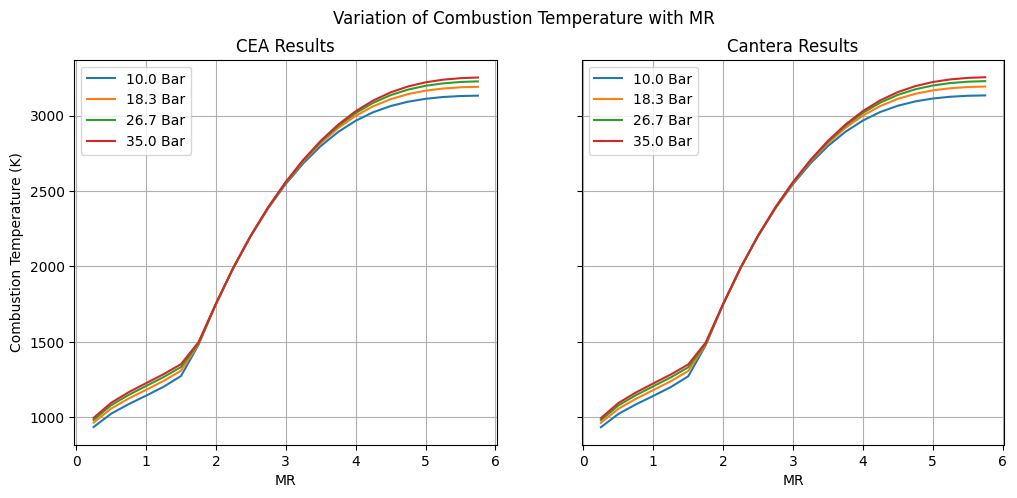

In [58]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, sharex= True, sharey=True, figsize=(12,5))

i = 0
for row in MR_array.T:
    
    axs[0].plot(MR_array[:,i], to_cea_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")
    axs[1].plot(MR_array[:,i], to_ctr_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")

    i += 1
    
axs[0].legend()
axs[1].legend()

axs[0].set_title("CEA Results")
axs[1].set_title("Cantera Results")

axs[0].set_xlabel("MR")
axs[1].set_xlabel("MR")

axs[0].set_ylabel("Combustion Temperature (K)")

axs[0].grid()
axs[1].grid()

fig.suptitle("Variation of Combustion Temperature with MR")

As can be seen, the combustion temperatures are significantly higher than we can plausibly accept for any reasonable MR. We must however consider the injector performance, as this normally has second order impacts on the combustion temperature.

c* is defined as the following:

$c^* = \frac{P_c A_t}{\dot{m}}$

We can derive the relationship between c* and the gas temperature to be as follows:

$c^* = \sqrt{\frac{T R}{\gamma} \left( \frac{\gamma + 1}{2} \right) ^{\frac{\gamma + 1}{\gamma -1 }})}$

We can assume thay any efficiency impact has negligible impact to the specific heat ratio of the specific gas constant of the resultant mixture, but only with the combustion temperature. Hence we can derive the following relationship for the $c^*$ efficiency with combustion temperature

$\eta_{c^*} = \frac{c^*_{act}}{c^*_{theo}} = \frac{\sqrt{T_{act}}}{\sqrt{T_{theo}}}$

Thus we can derive the actual combustion temperature as follows:

$T_{act} = T_{theo} \eta_{c^*}^2$

It should be noted that the assumption made that gas composition and specific heat ratio remain constant are unverified and can be gross, but it can be proximate for first pass sizing. The following c* efficiency has been assumed

In [63]:
%%render

eta_c = 0.90

<IPython.core.display.Latex object>

Based on this c* efficiency, we can now back calculate what our new combustion temperatures will be for the gas generators:

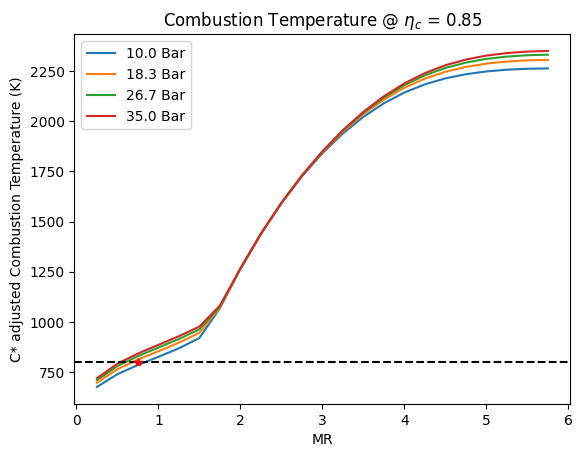

In [ ]:
i = 0
for row in P_array:
    plt.plot(O_F_array, T_add_array[:, i] * eta_c**2, label = f"{row:0.1f} Bar")
    
    i += 1

plt.legend()
plt.xlabel("MR")
plt.ylabel("C* adjusted Combustion Temperature (K)")
plt.title(fr"Combustion Temperature @ $\eta_c$ = {eta_c:0.2f}")
plt.axhline(800, linestyle="--", color="k")
plt.plot(0.75, 800, marker="*", color="r")

#### 3.1.2 - Specific Heat Capacity

Another quite improtant parameter to consider is the specific heat capacity of the gas, this will have critical implications on the required mass flow rate needed for the gas generator.

In [ ]:
P_array = np.array([25])

O_F_array = np.linspace(0.75, 6, 50)

cp_add_array = np.zeros((O_F_array.size, P_array.size))

cp_cant_array = np.zeros((O_F_array.size, P_array.size))

cp_cant_fz_array = np.zeros((O_F_array.size, P_array.size))

T_add_array = np.zeros((O_F_array.size, P_array.size))

i = 0
for o_f in O_F_array:

    k= 0
    for P in P_array:

        Cp_add = cea.get_Chamber_Cp(Pc=P, MR=o_f)

        cp_cant_fz = ctr.get_thermo_prop(Pcc=P * 1e5, MR=o_f).get_cp()

        cp_add_array[i, k]  = Cp_add

        cp_cant_fz_array[i, k] = cp_cant_fz

        k += 1

    i += 1

C:\Users\elias\AppData\Local\Temp\ipykernel_19184\3032516234.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cp_cant_fz_array[i, k] = cp_cant_fz


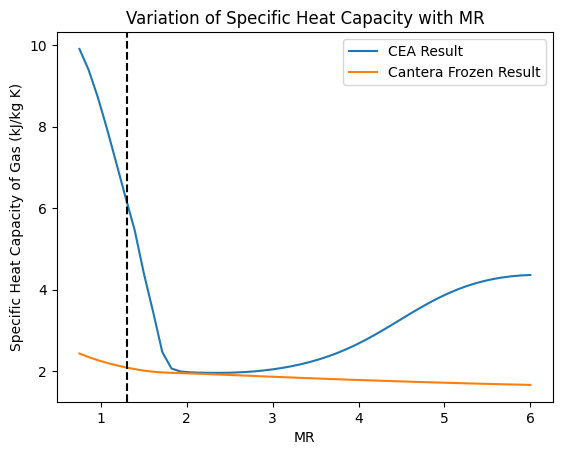

In [ ]:
i = 0
for row in P_array:
    plt.plot(O_F_array, cp_add_array[:, i]/1e3, label = f"CEA Result")
    # plt.plot(O_F_array, cp_cant_array[:, i] / 1e3, label=f"Cantera Result")
    plt.plot(O_F_array, cp_cant_fz_array[:, i] / 1e3, label=f"Cantera Frozen Result")

    i += 1
plt.legend()
plt.xlabel("MR")
plt.ylabel("Specific Heat Capacity of Gas (kJ/kg K)")
plt.title("Variation of Specific Heat Capacity with MR")
plt.axvline(1.3, linestyle="--", color="k")

#### 3.1.3 - Specific Heat Ratio

Another key parameter that is influential to the design of the turbopump, is the specific heat ratio ($\gamma$), which has been plotted below.

In [ ]:
P_array = np.linspace(5, 30, 5)

O_F_array = np.linspace(0.05, 2.25, 50)

R_array = np.zeros((O_F_array.size, P_array.size))

gamma_array = np.zeros((O_F_array.size, P_array.size))

i = 0
for o_f in O_F_array:

    k = 0
    for P in P_array:

        gamma = cea.get_Chamber_MolWt_gamma(Pc=P, MR=o_f)[1]

        gamma_array[i, k] = gamma

        R_array[i, k] = Cp_add*(gamma - 1)/gamma

        k += 1

    i += 1

Text(0.5, 1.0, 'Specific Heat Ratio at varying MR')

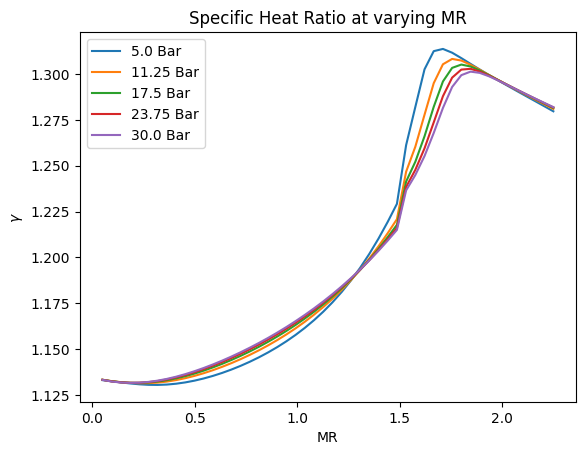

In [ ]:
i = 0
for row in P_array:
    plt.plot(O_F_array, gamma_array[:, i], label = f"{row} Bar")
    
    i += 1

plt.legend()
plt.xlabel("MR")
plt.ylabel(r"$\gamma$")
plt.title(fr"Specific Heat Ratio at varying MR")


#### 3.1.4 - Specific Gas Constant

The specific gas constant is an important parameter, as this will directly influence the gas generator exhaust density and thus areas producted for both the rotor and the stator.

In [ ]:
P_array = np.linspace(5, 30, 5)

O_F_array = np.linspace(0.05, 2.25, 50)

R_array = np.zeros((O_F_array.size, P_array.size))

gamma_array = np.zeros((O_F_array.size, P_array.size))

i = 0
for o_f in O_F_array:

    k = 0
    for P in P_array:

        Cp_add = cea.get_Chamber_Cp(Pc=P, MR=o_f)

        gamma = cea.get_Chamber_MolWt_gamma(Pc=P, MR=o_f)[1]

        gamma_array[i, k] = gamma

        R_array[i, k] = Cp_add*(gamma - 1)/gamma

        k += 1

    i += 1

In [64]:
i = 0
for row in P_array:
    plt.plot(O_F_array, R_array[:, i], label = f"{row} Bar")
    
    i += 1

plt.legend()
plt.xlabel("MR")
plt.ylabel(r"$R$ (kJ/kg)")
plt.title(fr"Specific Gas Constant at varying MR")


NameError: name 'P_array' is not defined

## 3 - Expected Performance Modelling

The previous study mainly focused on the theoretical performance results 